This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
# !pip install keras keras-hub --upgrade -q

In [2]:
# import os
# os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# # @title
# import os
# from IPython.core.magic import register_cell_magic

# @register_cell_magic
# def backend(line, cell):
#     current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
#     if current == required:
#         get_ipython().run_cell(cell)
#     else:
#         print(
#             f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
#             f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
#         )

## Classification and regression

### Classifying movie reviews: A binary classification example

#### The IMDb dataset

In [1]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Preparing the data

In [4]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

x_train.shape, x_train[0]

((25000, 10000), array([0., 1., 1., ..., 0., 0., 0.]))

#### Building your model

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential(
    [
        # Input(shape=(10000,)),
        Dense(16, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"), # бинарная классификация
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",         # бинарная классификация
    metrics=["accuracy"],
)

#### Validating your approach

In [9]:
# !rm -rf /content/aim_logs
import shutil
import os

def delete_directory(path):
    """Удаляет каталог и всё его содержимое"""
    try:
        shutil.rmtree(path)
        print(f"Каталог '{path}' успешно удалён")
    except FileNotFoundError:
        print(f"Каталог '{path}' не найден")
    except PermissionError:
        print(f"Нет прав для удаления '{path}'")
    except Exception as e:
        print(f"Ошибка при удалении: {e}")

# Использование
delete_directory('/content/aim_logs2')

Каталог '/content/aim_logs2' не найден


In [52]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=0
)

In [34]:
!pip install gradio plotly -q

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 🎛️ НАСТРОЙКИ
CONFIG = {
    "col_width": 550,              # ширина одной колонки
    "plot_height": 380,            # общая высота фигуры
    "margin": {"l": 50, "r": 40, "t": 60, "b": 40},
}

def plot_history(history, config=None, title="📊 Training Metrics"):
    """Строит интерактивные графики в сетке 1 строка × 2 колонки"""
    if config is None:
        config = CONFIG

    # Находим основные метрики (без val_)
    metrics = [m for m in history.history.keys() if not m.startswith('val_')]
    # Берём ровно 2 метрики для размещения в 1 строку (обычно loss и accuracy)
    metrics_to_plot = metrics[:2]

    # Создаём сетку 1x2
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=[m.replace('_', ' ').title() for m in metrics_to_plot],
        horizontal_spacing=0.12,
        shared_xaxes=True  # Синхронизируем масштаб по эпохам при зуме
    )

    for i, m in enumerate(metrics_to_plot, 1):
        # Train линия
        fig.add_trace(go.Scatter(
            y=history.history[m],
            name=f"Train {m}",
            mode='lines+markers',
            line=dict(width=2)
        ), row=1, col=i)

        # Validation линия (если есть)
        val_m = f'val_{m}'
        if val_m in history.history:
            fig.add_trace(go.Scatter(
                y=history.history[val_m],
                name=f"Val {m}",
                mode='lines+markers',
                line=dict(width=2, dash='dot')
            ), row=1, col=i)

    # Применяем настройки макета
    fig.update_layout(
        width=len(metrics_to_plot) * config["col_width"],
        height=config["plot_height"],
        margin=config["margin"],
        hovermode='x unified',
        title=title,
        template='plotly_white'
    )

    fig.show()

# Рисуем!
plot_history(history)

In [23]:
from IPython.display import clear_output
import plotly.graph_objects as go
from tensorflow.keras.callbacks import Callback

CONFIG = {
    "col_width": 700,              # ширина одной колонки
    "plot_height": 500,            # общая высота фигуры
    "margin": {"l": 50, "r": 40, "t": 60, "b": 40},
}

class LivePlotCallback(Callback):
    def __init__(self, num_epochs_show=5):
        super().__init__()
        self.num_epochs_show = num_epochs_show
        self.history = {'epoch': []}
        self.total_epochs = None

    def on_train_begin(self, logs=None):
        # Keras передаёт параметры обучения в self.params
        self.total_epochs = self.params.get('epochs', float('inf'))

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_epoch = epoch + 1
        self.history['epoch'].append(current_epoch)

        # 1. Динамически сохраняем ВСЕ пришедшие метрики
        for k, v in logs.items():
            if k not in self.history:
                self.history[k] = []
            self.history[k].append(v)

        # 2. Проверяем, пора ли обновлять график
        should_update = (current_epoch % self.num_epochs_show == 0) or \
                        (current_epoch == self.total_epochs)

        if should_update:
            self._render_plot()

    def _render_plot(self):
        clear_output(wait=True)
        fig = go.Figure()

        # 3. Автоматически находим базовые имена метрик (убираем 'val_')
        all_metrics = [m for m in self.history.keys() if m != 'epoch']
        base_metrics = sorted(list(set(m.replace('val_', '') for m in all_metrics)))

        for base in base_metrics:
            train_key = base
            val_key = f'val_{base}'

            # Train линия
            if train_key in self.history:
                fig.add_trace(go.Scatter(
                    x=self.history['epoch'],
                    y=self.history[train_key],
                    name=train_key,
                    mode='lines+markers',
                    marker=dict(size=6)
                ))

            # Val линия (пунктир)
            if val_key in self.history:
                fig.add_trace(go.Scatter(
                    x=self.history['epoch'],
                    y=self.history[val_key],
                    name=val_key,
                    mode='lines+markers',
                    line=dict(dash='dot'),
                    marker=dict(size=6)
                ))

        # 4. Применяем CONFIG
        fig.update_layout(
            width=CONFIG['col_width'],
            height=CONFIG['plot_height'],
            margin=CONFIG['margin'],
            hovermode='x unified',
            title="🔄 Live Training Metrics",
            xaxis_title="Epoch",
            template='plotly_white'
        )
        fig.show()

# === ИСПОЛЬЗОВАНИЕ ===
live_cb = LivePlotCallback(num_epochs_show=5) # Обновлять каждые 5 эпох
history = model.fit(
    partial_x_train, partial_y_train,
    epochs=20, batch_size=512,
    validation_data=(x_val, y_val),
    verbose=0,
    callbacks=[live_cb]
)

In [36]:
# !aim up --port 43800 --host 0.0.0.0 --repo ./aim_repo &

In [37]:
# !lsof -i :43800 || echo "Порт 5000 свободен"

In [70]:
# !kill 135281

In [37]:
# !pip install pyngrok -q
# !ngrok authtoken 2rDLisDE7TU2zCkc0xfSgmHD0rN_81FpGdewYSighKzTvjkRY

In [38]:
# !ps aux | grep ngrok

In [36]:
# !kill 39487

In [42]:
# from pyngrok import ngrok
# ngrok.kill()
# public_url = ngrok.connect(7861)
# print(f"✅ Aim UI доступен: {public_url}")

In [ ]:
# ngrok.kill()

In [36]:
# from IPython.display import IFrame, display

# # Показываем Aim UI прямо в ноутбуке
# display(IFrame(public_url, width='100%', height='600px'))

In [25]:
# from IPython.display import IFrame, display

# # Показываем Aim UI прямо в ноутбуке
# display(IFrame('http://0.0.0.0:43800', width='100%', height='600px'))

In [6]:
!pip install lcurvetools -q

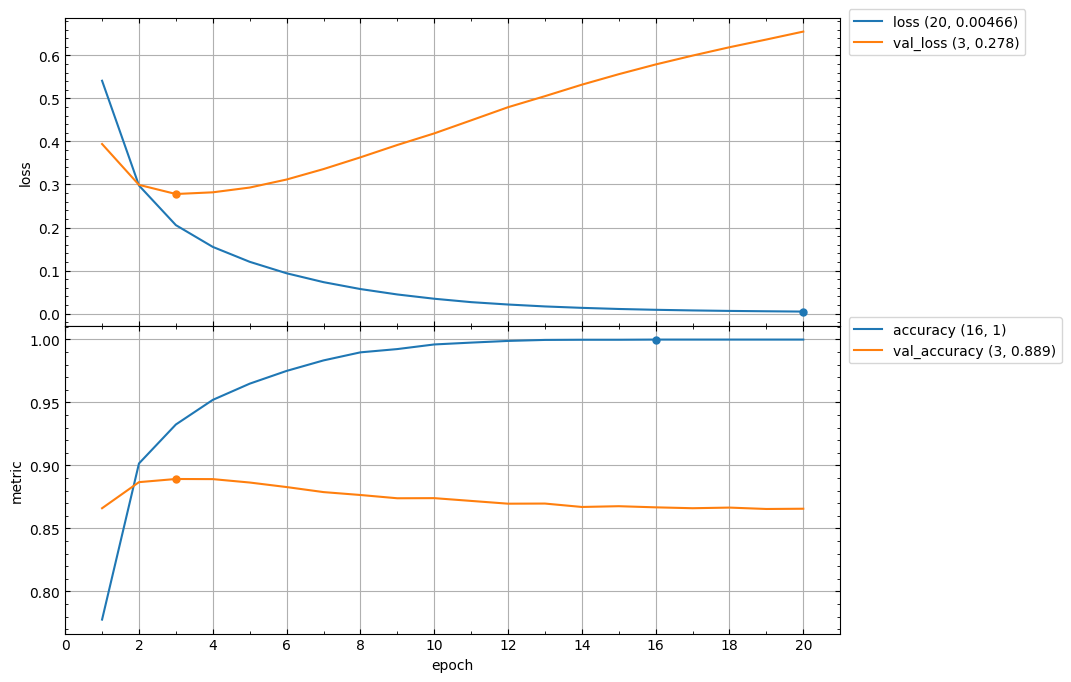

In [59]:
from lcurvetools import lcurves_by_history
lcurves_by_history(history.history, figsize=(10, 8));

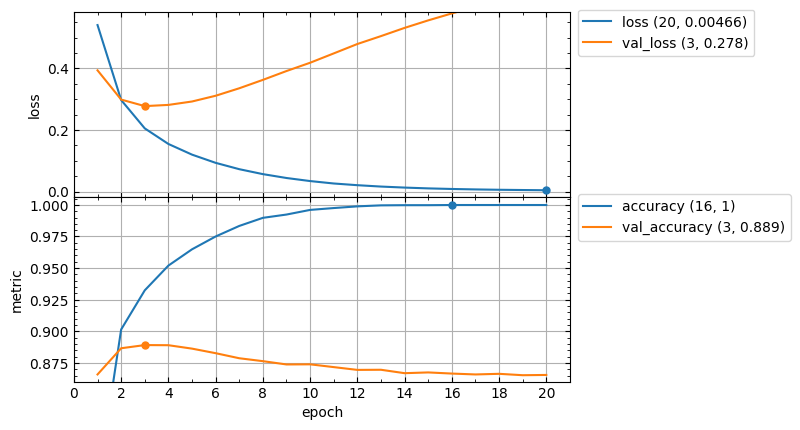

In [60]:
lcurves_by_history(history.history, epoch_range_to_scale=[5, 15]);

In [ ]:
# history = model.fit(
#     x_train,
#     y_train,
#     epochs=20,
#     batch_size=512,
#     validation_split=0.2,
# )

In [ ]:
# history_dict = history.history
# history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [47]:
!pip install plot-keras-history -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.4/327.4 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


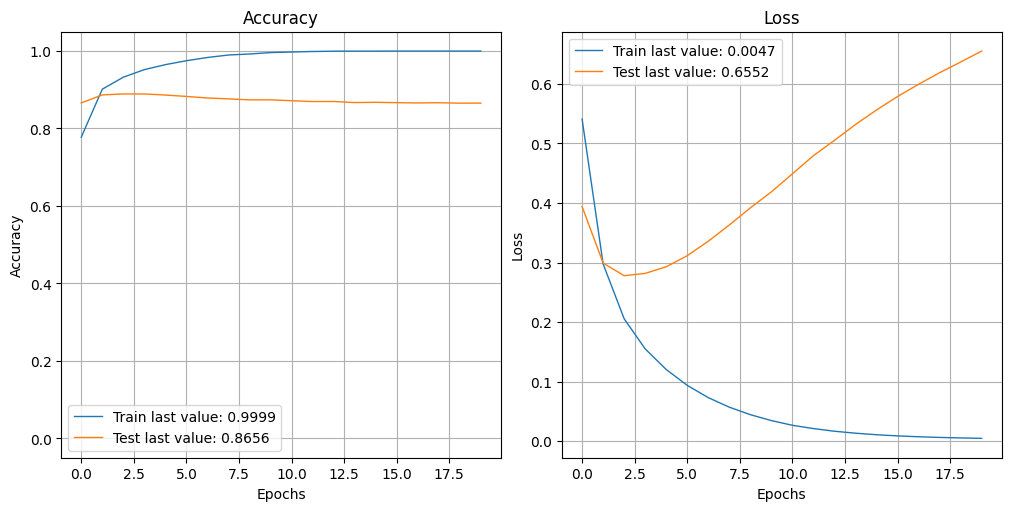

In [56]:
from plot_keras_history import show_history, plot_history
show_history(history)
# plot_history(history, path="training_report.png")  # Сохранит как один большой график

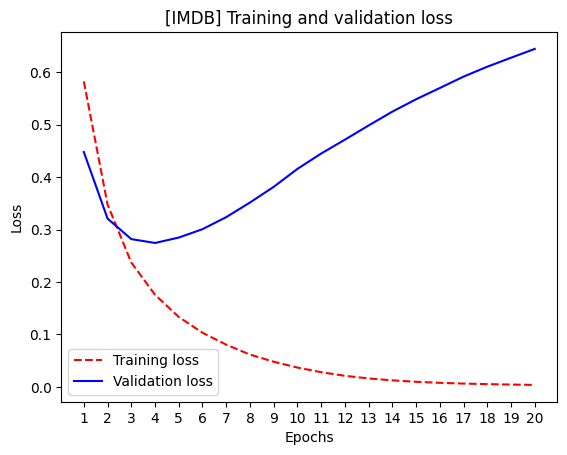

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

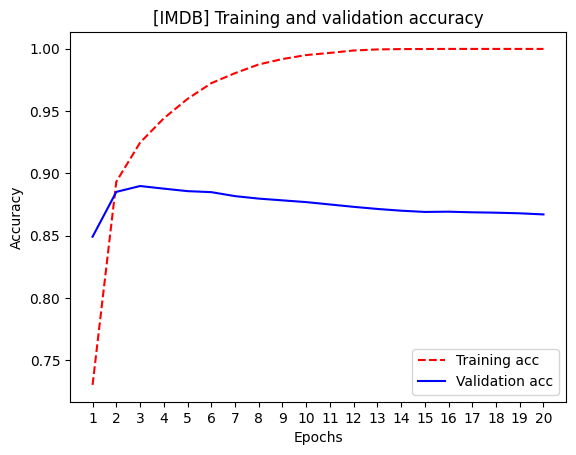

In [ ]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

In [ ]:
results

#### Using a trained model to generate predictions on new data

In [ ]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.00550594],
       [0.99999934],
       [0.677242  ],
       ...,
       [0.00104477],
       [0.00675541],
       [0.88898677]], dtype=float32)

#### Further experiments

#### Wrapping up

### Classifying newswires: A multiclass classification example

#### The Reuters dataset

In [ ]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

In [ ]:
train_data.shape

(8982,)

In [ ]:
len(test_data)

In [ ]:
train_data[10]

In [ ]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]]
)
train_labels[10]

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


np.int64(3)

#### Preparing the data

In [ ]:
x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)
x_train.shape, x_train[0]

((8982, 10000), array([0., 1., 1., ..., 0., 0., 0.]))

In [ ]:
# def one_hot_encode(labels, num_classes=46):
#     results = np.zeros((len(labels), num_classes))
#     for i, label in enumerate(labels):
#         results[i, label] = 1.0
#     return results

# y_train = one_hot_encode(train_labels)
# y_test = one_hot_encode(test_labels)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)
train_labels[0], y_train[0]

(np.int64(3),
 array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

#### Building your model

In [ ]:
model = Sequential(
    [
        Dense(64, activation="relu"),
        Dense(64, activation="relu"),
        Dense(46, activation="softmax"), # многоклассовая классификация
    ]
)
from tensorflow.keras.metrics import TopKCategoricalAccuracy
top_3_accuracy = TopKCategoricalAccuracy(k=3,
                                         name="top_3_accuracy"
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",    # многоклассовая классификация
    metrics=["accuracy", top_3_accuracy],
)

#### Validating your approach

In [ ]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [ ]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.3698 - loss: 3.1871 - top_3_accuracy: 0.5932 - val_accuracy: 0.5270 - val_loss: 2.3705 - val_top_3_accuracy: 0.6690
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6215 - loss: 1.8666 - top_3_accuracy: 0.7343 - val_accuracy: 0.6620 - val_loss: 1.5608 - val_top_3_accuracy: 0.7700
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7200 - loss: 1.3157 - top_3_accuracy: 0.8156 - val_accuracy: 0.7180 - val_loss: 1.2775 - val_top_3_accuracy: 0.8130
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7806 - loss: 1.0364 - top_3_accuracy: 0.8652 - val_accuracy: 0.7560 - val_loss: 1.1367 - val_top_3_accuracy: 0.8500
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8256 - loss: 0.8238 - top_3_accuracy: 0.9063 - val_accuracy: 0.7840 - val_loss: 1.0424 - val_top_3_accuracy: 0.8760
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8619 - loss: 0.6532 - top_3_ac

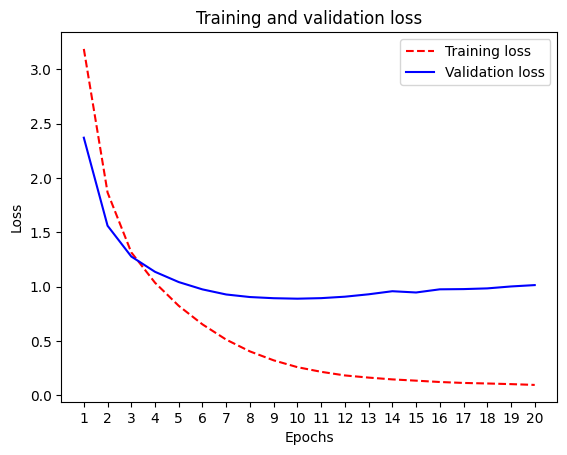

In [ ]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

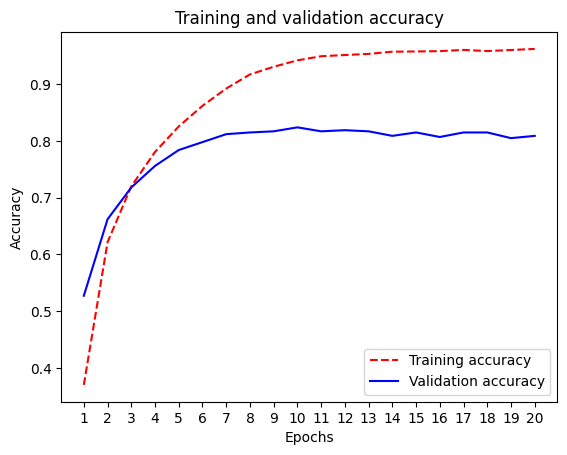

In [ ]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

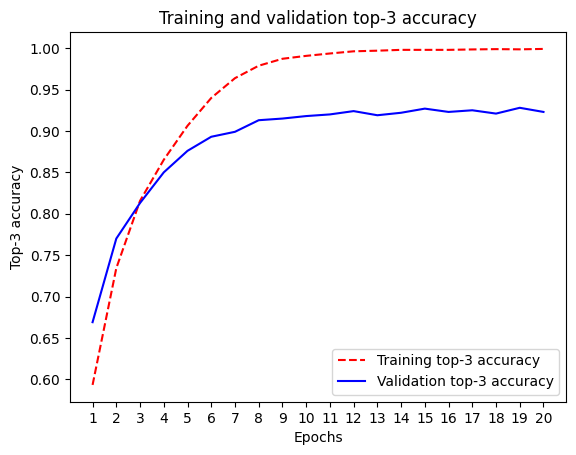

In [ ]:
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.show()

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512,
)
results = model.evaluate(x_test, y_test)

In [ ]:
results

In [ ]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels == test_labels_copy)
hits_array.mean()

#### Generating predictions on new data

In [ ]:
predictions = model.predict(x_test)

In [ ]:
predictions[0].shape

In [ ]:
np.sum(predictions[0])

In [ ]:
np.argmax(predictions[0])

#### A different way to handle the labels and the loss

In [ ]:
y_train = train_labels
y_test = test_labels

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

#### The importance of having sufficiently large intermediate layers

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
)

#### Further experiments

#### Wrapping up

### Predicting house prices: A regression example

#### The California Housing Price dataset

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = (
    california_housing.load_data(version="small")
)

In [ ]:
import pandas as pd
df = pd.DataFrame(data=train_data)
df.head()

,0,1,2,3,4,5,6,7
0,-122.239998,37.730000,21.0,7031.0,1249.0,2930.0,1235.0,4.5213
1,-122.279999,37.849998,48.0,2063.0,484.0,1054.0,466.0,2.2625
2,-122.290001,37.820000,2.0,158.0,43.0,94.0,57.0,2.5625
3,-122.290001,37.810001,46.0,935.0,297.0,582.0,277.0,0.7286
4,-122.180000,37.759998,37.0,1575.0,358.0,933.0,320.0,2.2917


In [ ]:
train_data.shape

In [ ]:
test_data.shape

In [ ]:
train_targets

#### Preparing the data

In [ ]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std
# Обратите внимание, что величины, используемые для нормализации контрольных данных,
# вычисляются с использованием обучающих данных. Никогда не следует использовать в
# работе какие-либо значения, вычисленные по контрольным данным, даже для таких простых шагов,
# как нормализация.


In [ ]:
y_train = train_targets / 100000
y_test = test_targets / 100000

In [ ]:
df = pd.DataFrame(data=x_train)
df.head()

,0,1,2,3,4,5,6,7
0,-0.176150,-1.594003,-2.424078,3.423944,2.589801,2.918909,2.800940,0.501960
1,-0.957497,0.888302,0.369453,0.058881,0.194700,0.089491,0.228324,-0.637887
2,-1.152871,0.267745,-4.389895,-1.231466,-1.186006,-1.358399,-1.139946,-0.486500
3,-1.152871,0.060919,0.162525,-0.705167,-0.390769,-0.622388,-0.403958,-1.411932
4,0.995797,-0.973447,-0.768652,-0.271664,-0.199787,-0.093004,-0.260105,-0.623152


#### Building your model

In [ ]:
def get_model():
        # Модель заканчивается одномерным слоем, не имеющим функции активации (это линейный слой).
        # Это типичная конфигурация для скалярной регрессии (целью которой является предсказание
        # одного значения на непрерывной числовой прямой).
        # Применение функции активации могло бы ограничить диапазон выходных значений;
        # например, если в последнем слое применить функцию активации sigmoid,
        # модель обучилась бы предсказывать только значения из диапазона между 0 и 1.
        # В данном случае, с линейным последним слоем, модель способна предсказывать
        # значения из любого диапазона.
    model = Sequential(
        [
            Dense(64, activation="relu"),
            Dense(64, activation="relu"),
            Dense(1),
        ]
    )
    # Обратите внимание, что модель компилируется с функцией потерь mse — mean squared error (среднеквадратичная ошибка),
    # вычисляющей квадрат разности между предсказанными и целевыми значениями. Эта функция широко используется в задачах регрессии.
    # Мы также включили новый параметр в мониторинг на этапе обучения: mae — mean absolute error (средняя абсолютная ошибка).
    # Это абсолютное значение разности между предсказанными и целевыми значениями. Например, значение MAE, равное 0,5,
    # в нашей задаче означает, что в среднем прогнозы отклоняются на 500 долларов США.
    # Понятие точности неприменимо для регрессии, поэтому для оценки качества часто берется средняя абсолютная ошибка (mean absolute error, MAE).
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model


#### Validating your approach using K-fold validation

In [ ]:
# import numpy as np

# k = 4
# num_val_samples = len(x_train) // k
# num_epochs = 50
# all_scores = []
# for i in range(k):
#     print(f"Processing fold #{i + 1}")
#     fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
#     fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
#     fold_x_train = np.concatenate(
#         [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
#         axis=0,
#     )
#     fold_y_train = np.concatenate(
#         [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
#         axis=0,
#     )
#     model = get_model()
#     model.fit(
#         fold_x_train,
#         fold_y_train,
#         epochs=num_epochs,
#         batch_size=16,
#         verbose=0,
#     )
#     scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
#     val_loss, val_mae = scores
#     all_scores.append(val_mae)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [ ]:
[round(value, 3) for value in all_scores]

In [ ]:
round(np.mean(all_scores), 3)

In [ ]:
# ручная кросс-валидация, без стратификации
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)

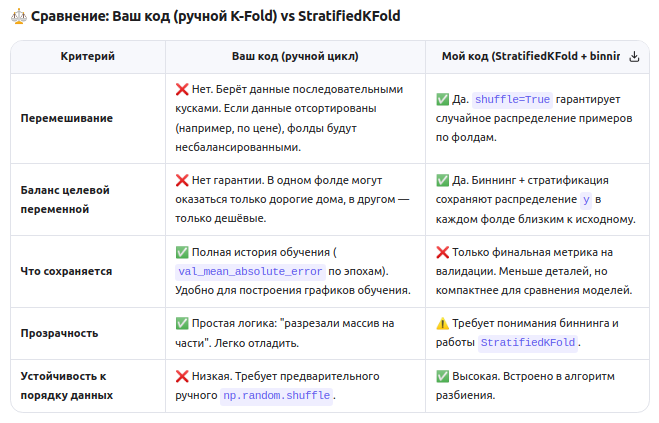

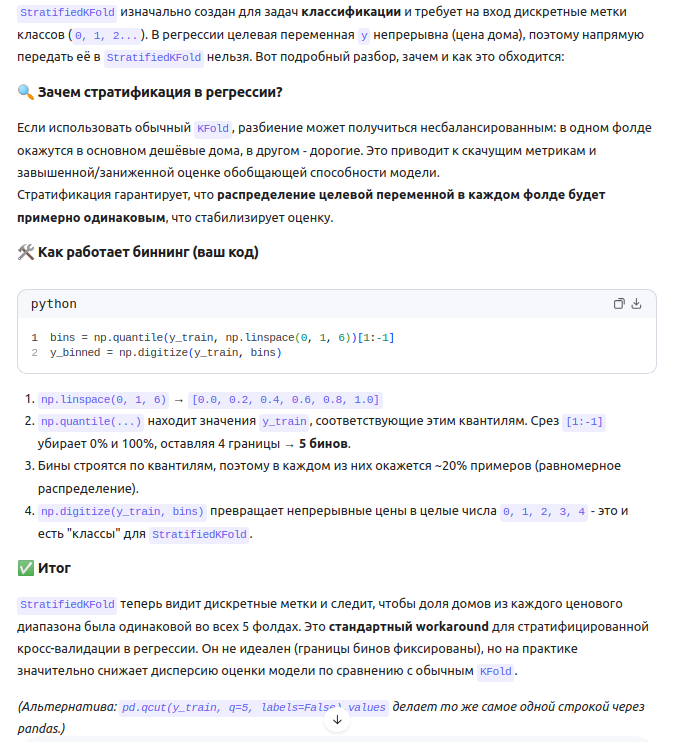

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Биннинг для стратификации
bins = np.quantile(y_train, np.linspace(0, 1, 6))[1:-1]
y_binned = np.digitize(y_train, bins)

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
all_mae_histories = []  # Для графиков
fold_scores = []        # Для итоговой оценки

num_epochs = 100
for train_idx, val_idx in skf.split(x_train, y_binned):
    model = get_model()
    history = model.fit(
        x_train[train_idx], y_train[train_idx],
        validation_data=(x_train[val_idx], y_train[val_idx]),
        epochs=num_epochs,
        batch_size=16,
        verbose=0
    )
    all_mae_histories.append(history.history['val_mean_absolute_error'])
    fold_scores.append(history.history['val_mean_absolute_error'][-1])

print(f"CV MAE: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
# Теперь all_mae_histories можно усреднить и построить график обучения

CV MAE: 0.3079 ± 0.0107


In [ ]:
y_binned

array([3, 1, 0, 0, 0, 1, 1, 4, 3, 4, 3, 3, 0, 4, 0, 2, 2, 3, 1, 2, 0, 0,
       0, 1, 4, 2, 3, 1, 2, 3, 2, 1, 4, 2, 1, 0, 0, 0, 4, 1, 4, 0, 2, 1,
       0, 1, 4, 2, 1, 1, 1, 0, 2, 4, 0, 0, 4, 0, 4, 4, 2, 4, 4, 2, 0, 3,
       3, 2, 3, 0, 1, 0, 2, 1, 2, 0, 4, 1, 1, 2, 3, 2, 3, 0, 2, 2, 0, 3,
       4, 2, 4, 2, 2, 2, 0, 4, 3, 2, 1, 1, 2, 1, 2, 2, 2, 1, 3, 4, 3, 1,
       1, 4, 2, 2, 2, 1, 2, 1, 0, 0, 1, 4, 0, 2, 3, 0, 0, 4, 3, 3, 2, 3,
       4, 2, 3, 4, 1, 1, 1, 4, 0, 2, 2, 1, 4, 0, 3, 0, 2, 0, 3, 2, 1, 0,
       2, 0, 4, 3, 0, 0, 0, 1, 4, 0, 3, 3, 4, 3, 2, 1, 3, 0, 4, 3, 1, 0,
       0, 3, 2, 4, 4, 1, 4, 3, 2, 3, 3, 2, 2, 2, 0, 3, 4, 3, 0, 2, 1, 1,
       0, 2, 4, 0, 1, 0, 4, 4, 3, 4, 3, 3, 2, 1, 2, 1, 0, 2, 3, 4, 4, 1,
       1, 2, 3, 3, 3, 1, 2, 0, 1, 1, 4, 3, 0, 3, 3, 2, 0, 4, 3, 3, 4, 1,
       3, 1, 4, 1, 1, 4, 0, 2, 1, 1, 4, 4, 0, 4, 4, 0, 4, 0, 3, 2, 2, 2,
       4, 4, 3, 4, 1, 0, 3, 3, 3, 1, 2, 1, 4, 4, 1, 4, 4, 4, 1, 1, 2, 3,
       0, 2, 3, 0, 1, 3, 2, 3, 4, 4, 2, 4, 4, 4, 3,

In [ ]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

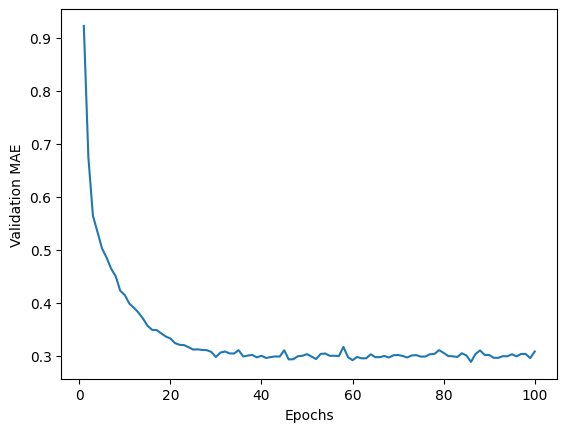

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

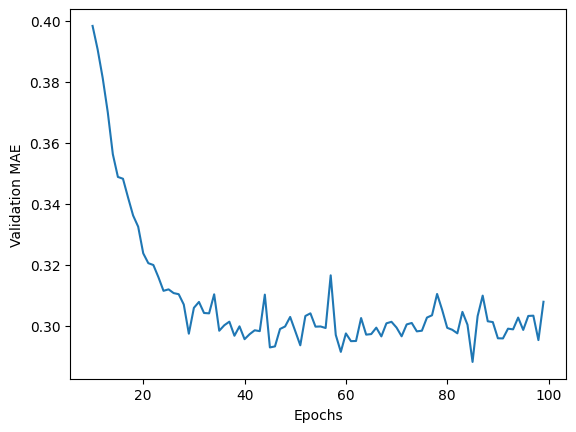

In [ ]:
truncated_mae_history = average_mae_history[10:]
epochs = range(10, len(truncated_mae_history) + 10)
plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [ ]:
model = get_model()
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)

In [ ]:
round(test_mean_absolute_error, 3)

#### Generating predictions on new data

In [ ]:
predictions = model.predict(x_test)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([2.0215442], dtype=float32)

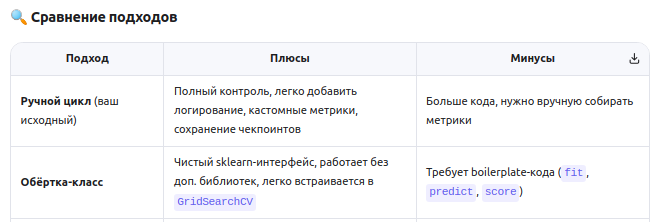

In [ ]:
# 📦 1. Обёртка-класс (sklearn-compatible)
# Создаём класс, наследующий BaseEstimator и RegressorMixin.
# Это позволяет скормить его в cross_val_score без циклов.

from sklearn.base import BaseEstimator, RegressorMixin
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
import numpy as np
from tensorflow.keras.backend import clear_session

class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, epochs=50, batch_size=16, random_state=42):
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.model = None

    def fit(self, X, y, **fit_params):
        # 🔥 Ключевая строка: сбрасываем граф перед созданием новой модели
        clear_session()

        self.model = Sequential([
            Input(shape=(X.shape[1],)),
            Dense(64, activation="relu"),
            Dense(64, activation="relu"),
            Dense(1)
        ])
        self.model.compile(optimizer="adam", loss="mse", metrics=["mae"])

        callbacks = [
            EarlyStopping(patience=10, restore_best_weights=True, monitor="val_mae"),
            ReduceLROnPlateau(factor=0.5, patience=5, monitor="val_mae")
        ]
        self.model.fit(X, y,
                       epochs=self.epochs,
                       batch_size=self.batch_size,
                       validation_split=0.2,
                       callbacks=callbacks,
                       verbose=0
        )
        return self

    def predict(self, X):
        return self.model.predict(X, verbose=0).flatten()

# Использование

# 1. Бинним цель для стратификации
bins = np.quantile(y_train, np.linspace(0, 1, 6))[1:-1]
y_binned = np.digitize(y_train, bins)

# 2. Генерируем индексы фолдов заранее
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=42
)
cv_splits = list(skf.split(x_train, y_binned))

# 3. Передаём готовые индексы в cross_val_score
wrapper = KerasRegressorWrapper(epochs=100, batch_size=16)
scores = cross_val_score(wrapper,
                         x_train, y_train,
                         cv=cv_splits,
                         scoring="neg_mean_absolute_error",
                         verbose=2
)
print(f"CV MAE: {-scores.mean():.4f} ± {scores.std():.4f}")

[CV] END .................................................... total time=   8.0s
[CV] END .................................................... total time=   5.6s
[CV] END .................................................... total time=   8.2s
[CV] END .................................................... total time=   9.4s
[CV] END .................................................... total time=  10.1s
CV MAE: 0.2807 ± 0.0245


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   41.3s finished


#### Wrapping up